In [1]:
# Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

In [2]:
# Download dataset
path = kagglehub.dataset_download("shilongzhuang/telecom-customer-churn-by-maven-analytics")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\shilongzhuang\telecom-customer-churn-by-maven-analytics\versions\1


In [3]:
# Load the CSV file
churn_data = pd.read_csv("telecom_customer_churn.csv")

In [4]:
# first few rows
churn_data.head(5)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [5]:
# descriptive statistics
descriptive_stats = churn_data.describe()

# Round the values 2d.p
descriptive_stats = descriptive_stats.round(2)

# Transpose the df
descriptive_stats = descriptive_stats.T

# Format the table for display
print(descriptive_stats.to_markdown(numalign="left", stralign="left"))

|                                   | count   | mean    | std     | min    | 25%     | 50%     | 75%     | max     |
|:----------------------------------|:--------|:--------|:--------|:-------|:--------|:--------|:--------|:--------|
| Age                               | 7043    | 46.51   | 16.75   | 19     | 32      | 46      | 60      | 80      |
| Number of Dependents              | 7043    | 0.47    | 0.96    | 0      | 0       | 0       | 0       | 9       |
| Zip Code                          | 7043    | 93486.1 | 1856.77 | 90001  | 92101   | 93518   | 95329   | 96150   |
| Latitude                          | 7043    | 36.2    | 2.47    | 32.56  | 33.99   | 36.21   | 38.16   | 41.96   |
| Longitude                         | 7043    | -119.76 | 2.15    | -124.3 | -121.79 | -119.6  | -117.97 | -114.19 |
| Number of Referrals               | 7043    | 1.95    | 3       | 0      | 0       | 0       | 3       | 11      |
| Tenure in Months                  | 7043    | 32.39   | 24.54 

In [6]:
def get_column_info_columnwise_segmented_missing(df, df_name):

    header_separator = "------------------------------------------------------------"  # separator

    print(header_separator)
    print(f"Column Information for: {df_name} (Missing Values Only)")
    print(header_separator)

    data_types_seen = set()  # track data types printed

    for data_type in df.dtypes.unique():  # iterate over unique data types
        filtered_cols = df.select_dtypes(include=[data_type]).columns
        missing_cols = []  # store columns with missing values for this data type

        for col in filtered_cols:
            missing_count = df[col].isnull().sum()
            if missing_count > 0:  # check missing values
                missing_cols.append(col)

        if missing_cols:  # only print if there are columns with missing values for this data type
            if data_types_seen:
                print("-" * len(header_separator))  # add separator if data types have been printed
            print(f"Data Type: {data_type}")
            print("-" * len(header_separator))
            data_types_seen.add(data_type)

            column_names = []
            data_types = []
            missing_counts = []
            missing_percentages = []

            for col in missing_cols:
                missing_count = df[col].isnull().sum()
                total_count = len(df)
                missing_percentage = (missing_count / total_count) * 100 if total_count > 0 else 0

                column_names.append(col)
                data_types.append(str(df[col].dtype))
                missing_counts.append(missing_count)
                missing_percentages.append(f"{missing_percentage:.2f}%")

            # Determine maximum column widths for formatting
            max_col_width = max(len(col) for col in column_names)
            max_dtype_width = max(len(dtype) for dtype in data_types)
            max_count_width = max(len(str(count)) for count in missing_counts)
            max_percentage_width = max(len(percentage) for percentage in missing_percentages)

            # Print the header
            print(f"{'Column Name':<{max_col_width + 2}} {'Data Type':<{max_dtype_width + 2}} {'Missing Count':<{max_count_width + 2}} {'Missing %':<{max_percentage_width + 2}}")
            print("-" * (max_col_width + max_dtype_width + max_count_width + max_percentage_width + 10))

            # Print the data
            for i in range(len(column_names)):
                print(f"{column_names[i]:<{max_col_width + 2}} {data_types[i]:<{max_dtype_width + 2}} {missing_counts[i]:<{max_count_width + 2}} {missing_percentages[i]:<{max_percentage_width + 2}}")

In [7]:
# Get column information for churn
get_column_info_columnwise_segmented_missing(churn_data, "Churn Data")

------------------------------------------------------------
Column Information for: Churn Data (Missing Values Only)
------------------------------------------------------------
Data Type: object
------------------------------------------------------------
Column Name              Data Type Missing Count Missing %
------------------------------------------------
Offer                    object   3877   55.05%  
Multiple Lines           object   682    9.68%   
Internet Type            object   1526   21.67%  
Online Security          object   1526   21.67%  
Online Backup            object   1526   21.67%  
Device Protection Plan   object   1526   21.67%  
Premium Tech Support     object   1526   21.67%  
Streaming TV             object   1526   21.67%  
Streaming Movies         object   1526   21.67%  
Streaming Music          object   1526   21.67%  
Unlimited Data           object   1526   21.67%  
Churn Category           object   5174   73.46%  
Churn Reason             object   

In [8]:
# filter rows where 'Internet Service' is 'No'
no_internet_service_data = churn_data[churn_data['Internet Service'] == 'No']

In [9]:
# Check if the columns are NaN for rows with 'No' Internet Service
missing_values_no_internet = no_internet_service_data[[
    'Internet Type',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data',
]].isnull().sum()

In [10]:
# check if all rows with 'No' Internet Service have NaN for the selected columns
if missing_values_no_internet.sum() == len(no_internet_service_data) * len(missing_values_no_internet):
    print("All columns are NaN for rows with 'No' Internet Service. ✅")
else:
    print("⚠️ Some columns still have non-NaN values for rows with 'No' Internet Service.")

All columns are NaN for rows with 'No' Internet Service. ✅


In [11]:
# filter rows where 'Internet Service' is 'Yes'
internet_service_yes = churn_data[churn_data['Internet Service'] == 'Yes']

In [12]:
# display the unique entries for each of the selected columns
unique_entries = internet_service_yes[['Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 
                                       'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data']].apply(lambda x: x.unique())

In [13]:
# print the unique entries for each column
for column, entries in unique_entries.items():
    print(f"Unique entries in '{column}':")
    print(entries)
    print("\n" + "-"*40 + "\n")

Unique entries in 'Internet Type':
['Cable' 'Fiber Optic' 'DSL']

----------------------------------------

Unique entries in 'Online Security':
['No' 'Yes']

----------------------------------------

Unique entries in 'Online Backup':
['Yes' 'No']

----------------------------------------

Unique entries in 'Device Protection Plan':
['No' 'Yes']

----------------------------------------

Unique entries in 'Premium Tech Support':
['Yes' 'No']

----------------------------------------

Unique entries in 'Streaming TV':
['Yes' 'No']

----------------------------------------

Unique entries in 'Streaming Movies':
['No' 'Yes']

----------------------------------------

Unique entries in 'Streaming Music':
['No' 'Yes']

----------------------------------------

Unique entries in 'Unlimited Data':
['Yes' 'No']

----------------------------------------



In [14]:
# filter rows where 'Internet Service' is 'No'
no_internet_service_data = churn_data[churn_data['Internet Service'] == 'No']

In [15]:
# check if all 'Avg Monthly GB Download' values are NaN in these rows
if no_internet_service_data['Avg Monthly GB Download'].isna().all():
    print("✅ All rows with 'No' Internet Service have NaN in 'Avg Monthly GB Download'.")
else:
    print("✖️ Some rows with 'No' Internet Service still have non-NaN values in 'Avg Monthly GB Download'.")

✅ All rows with 'No' Internet Service have NaN in 'Avg Monthly GB Download'.


In [16]:
churn_data[churn_data['Phone Service'] == 'No'][['Avg Monthly Long Distance Charges', 'Multiple Lines']].isnull().sum()

Avg Monthly Long Distance Charges    682
Multiple Lines                       682
dtype: int64

In [17]:
# replace NaN values with "No" for rows where 'Internet Service' is 'No'
columns_to_replace = ['Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 
                      'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 
                      'Streaming Music', 'Unlimited Data']

churn_data.loc[churn_data['Internet Service'] == 'No', columns_to_replace] = "No"

churn_data.loc[churn_data['Internet Service'] == 'No', 'Avg Monthly GB Download'] = 0

churn_data.loc[churn_data['Phone Service'] == 'No', 'Avg Monthly Long Distance Charges'] = 0

churn_data.loc[churn_data['Phone Service'] == 'No', 'Multiple Lines'] = "No"

churn_data['Offer'] = churn_data['Offer'].fillna("No Offer")

churn_data = churn_data.drop(columns=['Customer ID', 'City', 'Churn Category', 'Churn Reason'])

In [18]:
# Get column information for churn
get_column_info_columnwise_segmented_missing(churn_data, "Churn Data")

------------------------------------------------------------
Column Information for: Churn Data (Missing Values Only)
------------------------------------------------------------


In [19]:
# churn_data = churn_data.dropna()

# # check if any NaN values remain in previously missing columns
# missing_cols = churn_data.isna().sum()
# missing_cols = missing_cols[missing_cols > 0]  # filter only columns that had NaN

# print(missing_cols)

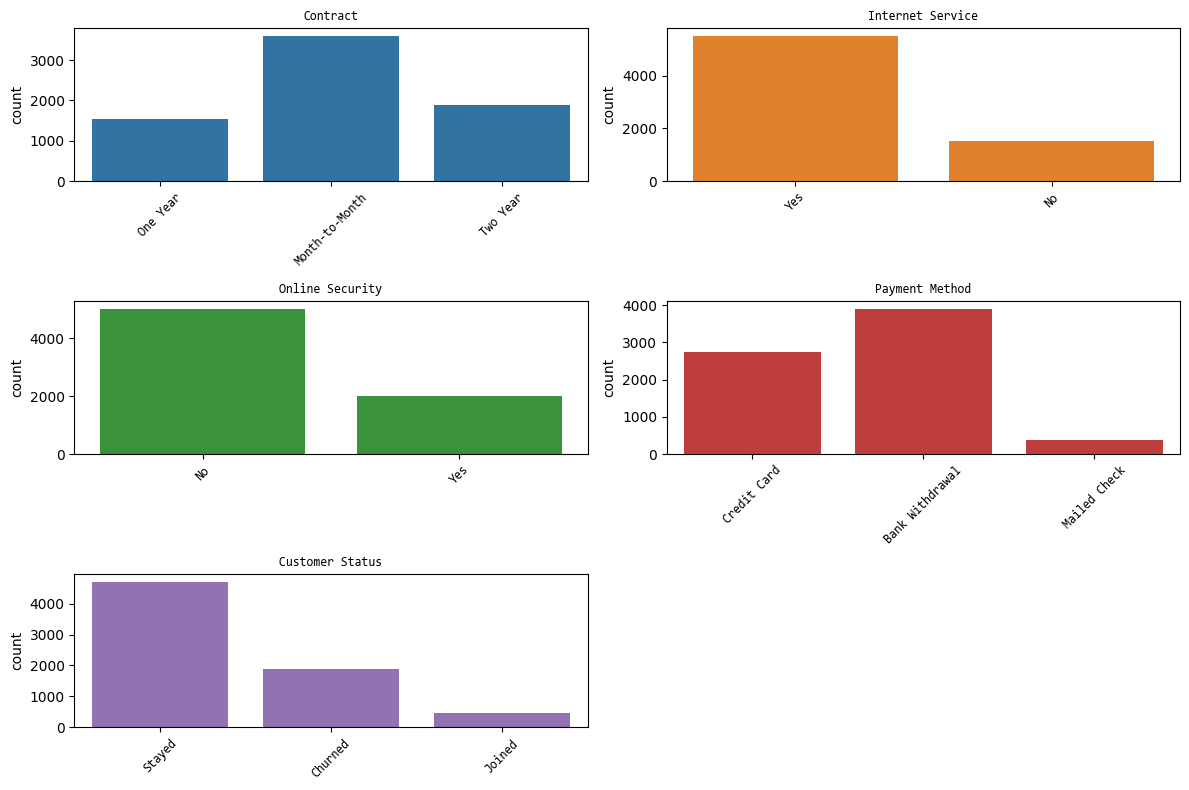

In [ ]:
# define categorical variables
important_categoricals = ["Contract", "Internet Service", "Online Security", "Payment Method", "Customer Status"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# set figure size and layout
plt.figure(figsize=(12, 8))
grid_size = 3  

for i, (col, color) in enumerate(zip(important_categoricals, colors), 1):
    plt.subplot(grid_size, 2, i)
    sns.countplot(data=churn_data, x=col, color=color)  
    plt.title(col, fontsize=9, fontname="Consolas")
    plt.xlabel("")
    plt.xticks(rotation=45, fontsize=9, fontname="Consolas")

plt.tight_layout()
plt.show()

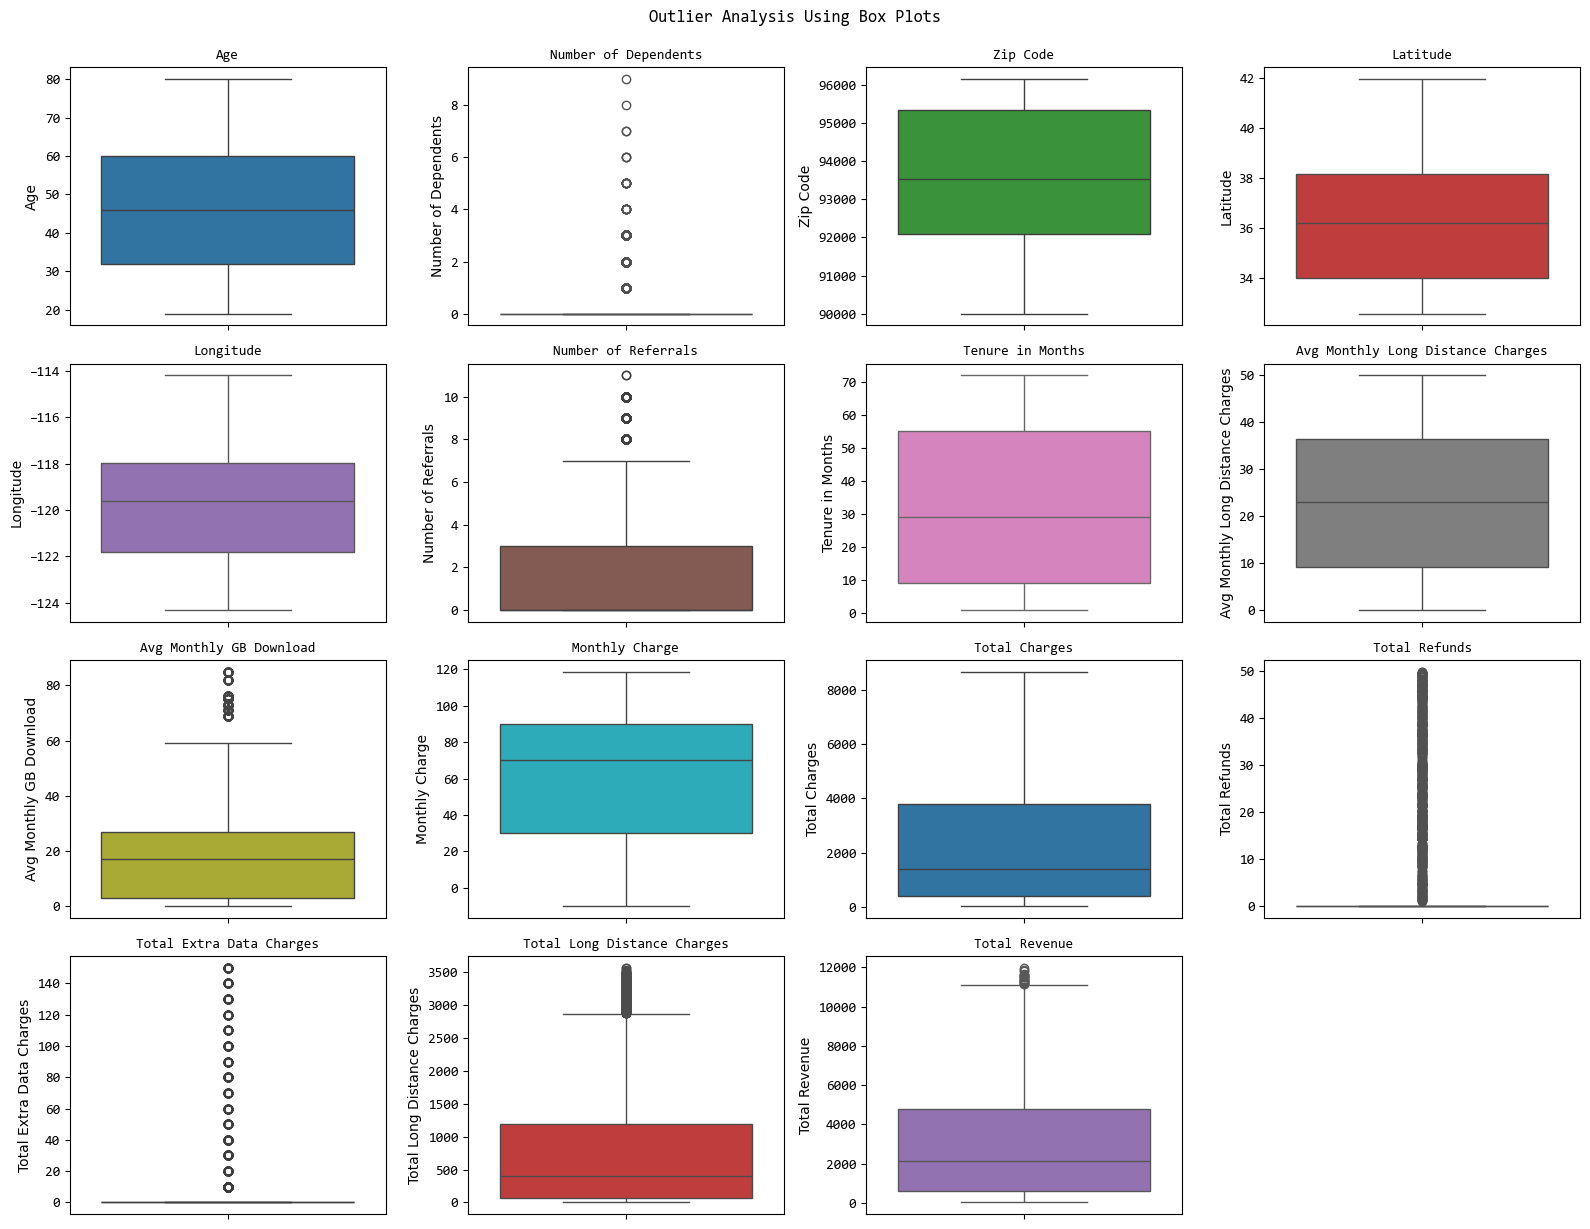

In [21]:
# select numerical columns
numerical_cols = churn_data.select_dtypes(include=['number']).columns

# grid size (n x n)
num_features = len(numerical_cols)
grid_size = int(np.ceil(np.sqrt(num_features)))  

# define colors
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]
    
colors = colors * (num_features // len(colors) + 1)

# set figure size dynamically
plt.figure(figsize=(grid_size * 4, grid_size * 3))

# loop through numerical columns and create boxplots
for i, (col, color) in enumerate(zip(numerical_cols, colors), 1):
    plt.subplot(grid_size, grid_size, i)
    sns.boxplot(y=churn_data[col], color=color)  
    plt.title(col, fontsize=10, fontname="Consolas")
    plt.xticks(fontsize=10, fontname="Consolas")
    plt.yticks(fontsize=10, fontname="Consolas")

# adjust layout
plt.tight_layout()
plt.suptitle("Outlier Analysis Using Box Plots", fontsize=12, fontname="Consolas", y=1.02)

# show plot
plt.show()

###### 🎯 Significant outliers are present in Total Refunds, Total Extra Data Charges, Total Long Distance Charges, and Number of Referrals, indicating potential data anomalies.

###### 🎯 Avg Monthly GB Download and Total Revenue also show notable outliers.

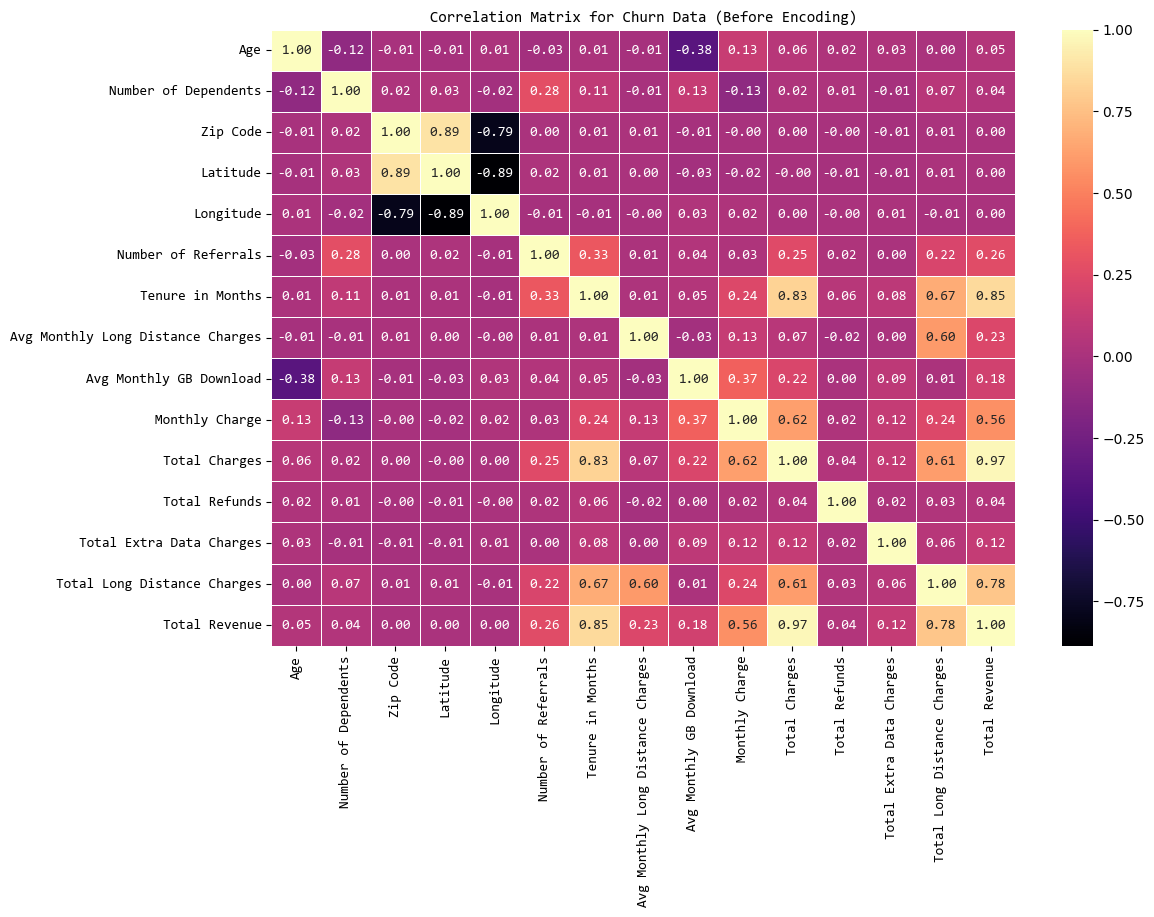

In [12]:
# Compute correlation matrix (only for numerical columns)
correlation_matrix = churn_data.select_dtypes(include=['number']).corr()

# Set figure size
plt.figure(figsize=(12, 8))

# Create a heatmap with custom styling
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="magma",  # Use a non-default color map (you can try 'coolwarm', 'viridis', 'magma', etc.)
    linewidths=0.5, 
    annot_kws={"fontsize": 10, "fontname": "Consolas"}  # Custom font for labels
)

# Apply Consolas font for title and labels
plt.title("Correlation Matrix for Churn Data (Before Encoding)", fontsize=11, fontname="Consolas")
plt.xticks(fontsize=10, fontname="Consolas")
plt.yticks(fontsize=10, fontname="Consolas")

# Show plot
plt.show()

##### 🎯 Insights from the Correlation Matrix

###### ✅ Total Revenue has a strong positive correlation with Total Charges (0.97) and Total Long Distance Charges (0.78).

###### ✅ Total Charges is highly correlated with Tenure (0.85) and Monthly Charge (0.62).

###### ✅ Tenure shows a moderate correlation with Total Long Distance Charges (0.67).

###### ✅ Monthly Charge has a moderate correlation with Avg Monthly GB Download (0.37).

###### ✅ Age has a negative correlation with Avg Monthly GB Download (-0.38).

###### ✅ Latitude and Longitude have a strong negative correlation (-0.89), indicating a geographic pattern.

In [13]:
# Ensure no implicit downcasting
pd.set_option('future.no_silent_downcasting', True)

# Copy the DataFrame before modifying
churn_data = churn_data.copy()

# Binary Encoding (Yes/No, Male/Female, etc.)
binary_cols = ['Gender', 'Married', 'Phone Service', 'Multiple Lines', 'Internet Service', 
               'Online Security', 'Online Backup', 'Device Protection Plan', 
               'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 
               'Streaming Music', 'Unlimited Data', 'Paperless Billing']

# Explicitly infer object types first
churn_data[binary_cols] = churn_data[binary_cols].infer_objects(copy=False)
churn_data[binary_cols] = churn_data[binary_cols].replace({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}).astype(int)

# One-Hot Encoding (Nominal Categories)
nominal_cols = ['Offer', 'Internet Type', 'Contract', 'Payment Method']
churn_data = pd.get_dummies(churn_data, columns=nominal_cols, drop_first=True)

# Ordinal Encoding (Ordered Categories)
ordinal_mapping = {'Joined': 0, 'Stayed': 1, 'Churned': 2}
churn_data['Customer Status'] = churn_data['Customer Status'].map(ordinal_mapping)

# Display the first few rows to verify encoding
churn_data.head()

,Gender,Age,Married,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Phone Service,...,Offer_Offer C,Offer_Offer D,Offer_Offer E,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No,Contract_One Year,Contract_Two Year,Payment Method_Credit Card,Payment Method_Mailed Check
0,0,37,1,0,93225,34.827662,-118.999073,2,9,1,...,False,False,False,False,False,False,True,False,True,False
1,1,46,0,0,91206,34.162515,-118.203869,0,9,1,...,False,False,False,False,False,False,False,False,True,False
2,1,50,0,0,92627,33.645672,-117.922613,0,4,1,...,False,False,True,False,True,False,False,False,False,False
3,1,78,1,0,94553,38.014457,-122.115432,1,13,1,...,False,True,False,False,True,False,False,False,False,False
4,0,75,1,0,93010,34.227846,-119.079903,3,3,1,...,False,False,False,False,True,False,False,False,True,False


In [14]:
churn_data.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target variable (y)
X = churn_data.drop(columns=['Customer Status'])  # Features
y = churn_data['Customer Status']  # Target

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Logistic Regression Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8147622427253371

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.70      0.68        91
           1       0.90      0.88      0.89       944
           2       0.66      0.67      0.66       374

    accuracy                           0.81      1409
   macro avg       0.74      0.75      0.74      1409
weighted avg       0.82      0.81      0.82      1409



###### 🎯 Logistic Regression performs well, especially for Class 1, but struggles slightly with Classes 0 and 2. While it is slightly less effective than XGBoost and Random Forest, it remains a reliable baseline model with strong generalization.

In [17]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8396025550035486

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.67      0.69        91
           1       0.88      0.95      0.91       944
           2       0.75      0.60      0.66       374

    accuracy                           0.84      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.83      0.84      0.83      1409



###### 🎯 Random Forest performs almost as well as XGBoost, excelling in Class 1 but slightly weaker in Class 2 due to lower recall. It remains a strong and balanced model for this dataset.

In [18]:
# XGBoost Model (Fixed Warning Issue)
xgb_model = XGBClassifier(objective="multi:softmax", eval_metric="mlogloss", random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("\nXGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.8502484031227822

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70        91
           1       0.90      0.93      0.92       944
           2       0.73      0.69      0.71       374

    accuracy                           0.85      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.85      0.85      0.85      1409



###### 🎯 XGBoost performs significantly better than Naïve Bayes, with strong classification ability, especially for Class 1. It offers better overall balance across all categories, making it a good choice for this dataset. 

In [19]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.6799148332150461

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.28      1.00      0.44        91
           1       0.91      0.76      0.83       944
           2       0.50      0.40      0.44       374

    accuracy                           0.68      1409
   macro avg       0.56      0.72      0.57      1409
weighted avg       0.76      0.68      0.70      1409



###### 🎯 Naïve Bayes performs well for class 1 but struggles with class 0 and class 2, leading to imbalanced predictions. It might not be the best choice for this dataset, especially if balanced classification is required.

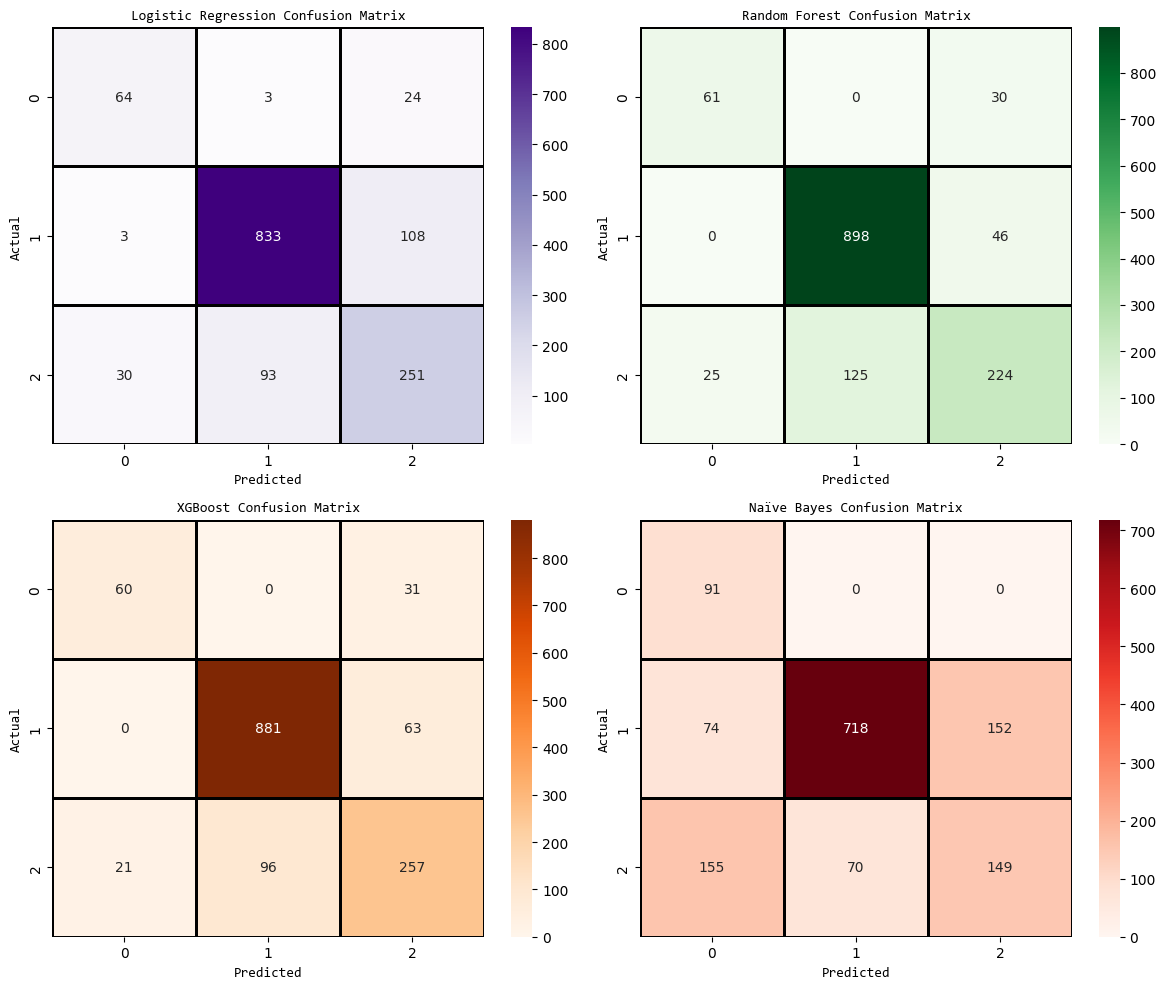

In [20]:
from sklearn.metrics import confusion_matrix

# Define custom color maps for each model
color_maps = {
    "Logistic Regression": "Purples",
    "Random Forest": "Greens",
    "XGBoost": "Oranges",
    "Naïve Bayes": "Reds"
}

# Function to plot multiple confusion matrices in a grid
def plot_confusion_matrices(models, y_true, y_preds, nrows=2, ncols=2):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
    axes = axes.flatten()  # Flatten for easy iteration

    for idx, (model_name, y_pred) in enumerate(zip(models.keys(), y_preds)):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap=color_maps[model_name], 
            xticklabels=np.unique(y_true), yticklabels=np.unique(y_true),
            linewidths=1, linecolor="black", ax=axes[idx]
        )
        axes[idx].set_xlabel("Predicted", fontsize=10, fontfamily="Consolas")
        axes[idx].set_ylabel("Actual", fontsize=10, fontfamily="Consolas")
        axes[idx].set_title(f"{model_name} Confusion Matrix", fontsize=10, fontfamily="Consolas")

    plt.tight_layout()  # Adjust layout for better fit
    plt.show()

# Define models and their predictions
models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Naïve Bayes": y_pred_nb
}

# Plot the confusion matrices in a 2x2 grid
plot_confusion_matrices(models, y_test, list(models.values()))


#####                                                     📓 Key Observations
#####  🎯 Logistic Regression

######    ✅ Performs well in predicting the majority class (class 1).

######    ✅ Some misclassification in class 2 (93 misclassified as 1, 30 as 0).

#####  🎯 Random Forest

######    ✅ Highest accuracy in predicting class 1 (898 correct predictions).

######    ✅ Relatively better at distinguishing class 2 but still misclassifies 125 cases as class 1.

######    ✅ Overall well-balanced performance.

#####  🎯 XGBoost

######    ✅ Similar to Random Forest, performs well in predicting class 1.

######    ✅ Slightly fewer misclassifications than Logistic Regression.

######    ✅ Performs slightly better on class 2 compared to Random Forest.

#####  🎯 Naïve Bayes

######    ✅ Performs poorly in predicting class 2 (many misclassifications).

######    ✅ Overestimates class 1, misclassifying a significant number of class 0 and 2 instances.

######    ✅ Less effective compared to tree-based models.

##### ⛓️‍💥 Overall Conclusion

######    ✅ Random Forest and XGBoost provide the best classification results, especially for class 1 and 2.

######    ✅ Logistic Regression performs reasonably well but misclassifies some cases.

######    ✅ Naïve Bayes struggles with multi-class classification, especially for class 2.

######  💡 In the case of interpretability and speed are priorities, Logistic Regression might still be useful, but for overall performance, Random Forest or XGBoost would be better choices.

In [21]:
# Get feature importances
rf_importance = rf_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

# Convert to DataFrame
feature_names = X.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Random Forest Importance": rf_importance,
    "XGBoost Importance": xgb_importance
})

# Sort by importance
importance_df = importance_df.sort_values(by="XGBoost Importance", ascending=False)


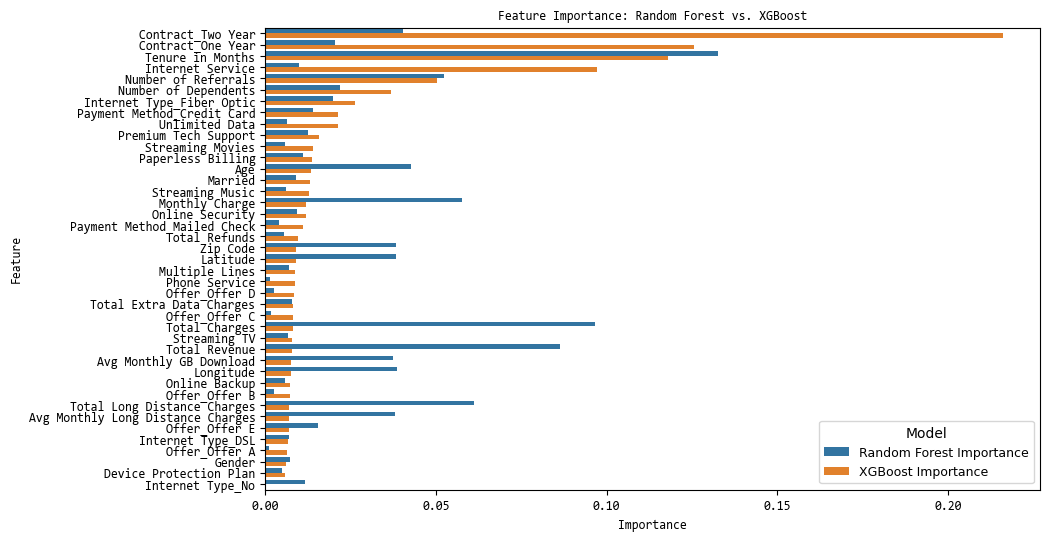

In [22]:
# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.melt(id_vars=["Feature"], var_name="Model", value_name="Importance"),
    x="Importance", y="Feature", hue="Model", palette=["#1f77b4", "#ff7f0e"]
)
plt.xlabel("Importance", fontsize=9, fontname="Consolas")
plt.ylabel("Feature", fontsize=9, fontname="Consolas")
plt.title("Feature Importance: Random Forest vs. XGBoost", fontsize=9, fontname="Consolas")
plt.legend(title="Model", fontsize=9)

# Set the font and size for the x and y axis ticks
plt.xticks(fontsize=9, fontname="Consolas")
plt.yticks(fontsize=9, fontname="Consolas")

plt.show()

#####                                                   Key Observations

#####  🎯 Most Influential Features

######    ✅ Contract Type (Two-Year & One-Year) - These features have the highest importance for both models, with XGBoost assigning them the highest weight.

######    ✅ Tenure in Months & Internet Service - These also play a crucial role in predicting churn.

##### 🎯 Differences in Model Behavior

######    ✅ Random Forest places more emphasis on features like Total Charges, Total Revenue, and Monthly Charges.

######    ✅ XGBoost assigns higher importance to categorical variables like Contract Type and Internet Type.

##### 🎯 Lower Importance Features

######    ✅ Some features such as Gender, Device Protection Plan, and Internet Type No have very low importance for both models, meaning they contribute less to the prediction.